<a href="https://colab.research.google.com/github/tanishataranoon/MY_ML_project/blob/main/toxic_text_classification_comparison_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud transformers torch --quiet

In [2]:
import pandas as pd
import tensorflow as tf
import numpy as np

In [120]:

import pickle


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 5)

In [4]:
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [5]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [6]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [7]:
import string
nltk.download('omw-1.4')

sns.set_theme(style='whitegrid')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [8]:
import re
from collections import Counter

# Load dataset
from https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge?library=datasets


In [9]:
from datasets import load_dataset

df = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [10]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

In [11]:
train_df = df['train'].to_pandas()
test_df = df['test'].to_pandas()

Train data size and trained data

In [12]:
print(train_df.shape)
print(train_df.head())

(159571, 8)
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


In [13]:
print('Columns: ', train_df.columns.tolist())

Columns:  ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [14]:
print('\nData Types: \n', train_df.dtypes)


Data Types: 
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


In [15]:
print('\nMissing values:\n', train_df.isnull().sum())


Missing values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Test data size and test data

In [16]:
print(test_df.shape)
print(test_df.head())

(306328, 8)
                 id                                       comment_text  toxic  \
0  00001cee341fdb12  Yo bitch Ja Rule is more succesful then you'll...    NaN   
1  0000247867823ef7  == From RfC == \n\n The title is fine as it is...    NaN   
2  00013b17ad220c46  " \n\n == Sources == \n\n * Zawe Ashton on Lap...    NaN   
3  00017563c3f7919a  :If you have a look back at the source, the in...    NaN   
4  00017695ad8997eb          I don't anonymously edit articles at all.    NaN   

   severe_toxic  obscene  threat  insult  identity_hate  
0           NaN      NaN     NaN     NaN            NaN  
1           NaN      NaN     NaN     NaN            NaN  
2           NaN      NaN     NaN     NaN            NaN  
3           NaN      NaN     NaN     NaN            NaN  
4           NaN      NaN     NaN     NaN            NaN  


**Binary 'any_toxic' column **




In [17]:
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_df['any_toxic'] = train_df[label_cols].max(axis=1)


print(f'Total comments    : {len(train_df):,}')
print(f'Toxic comments    : {train_df["any_toxic"].sum():,} ({train_df["any_toxic"].mean()*100:.1f}%)')
print(f'Non-toxic comments: {(train_df["any_toxic"]==0).sum():,} ({(train_df["any_toxic"]==0).mean()*100:.1f}%)')

Total comments    : 159,571
Toxic comments    : 16,225 (10.2%)
Non-toxic comments: 143,346 (89.8%)


In [18]:
# print(f'Total comments : {len(df):,}')
# print(f'Total toxic comments : {len(train_df[train_df.any_toxic == 1]):,}')
# print(f'Total non-toxic comments : {len(train_df[train_df.any_toxic == 0]):,}')

# Exploratory Data Analysis (EDA)

In [19]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


Bar Chart of Number of Comments per Toxicity Label \
A pie chart for non-toxic vs toxic

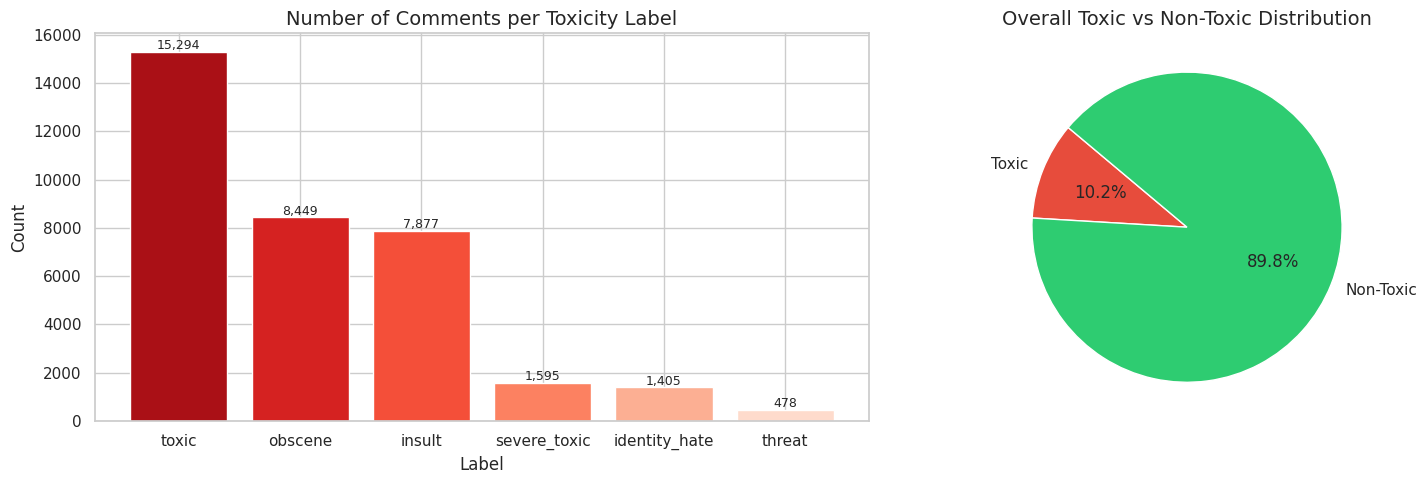

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('Reds_r', len(label_cols)))
axes[0].set_title('Number of Comments per Toxicity Label', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    [train_df['any_toxic'].sum(), (train_df['any_toxic']==0).sum()],
    labels=['Toxic', 'Non-Toxic'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140
)
axes[1].set_title('Overall Toxic vs Non-Toxic Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



In [21]:
co_matrix = train_df[label_cols].T.dot(train_df[label_cols])
co_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


Multi-label Co-occurrence Heatmap a comment can belong to multiple categories at the same time

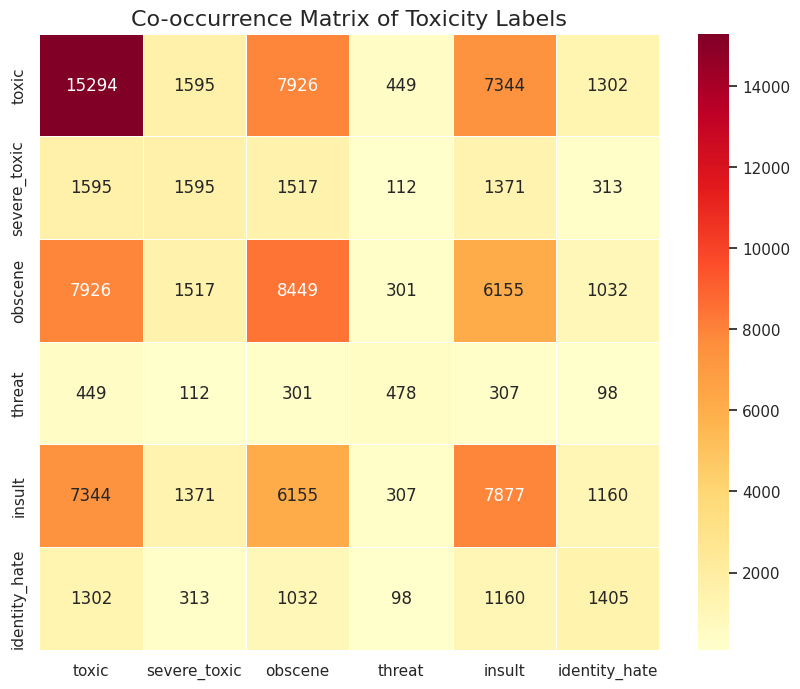

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Toxicity Labels', fontsize=16)
plt.savefig('co_occurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Word Cloud

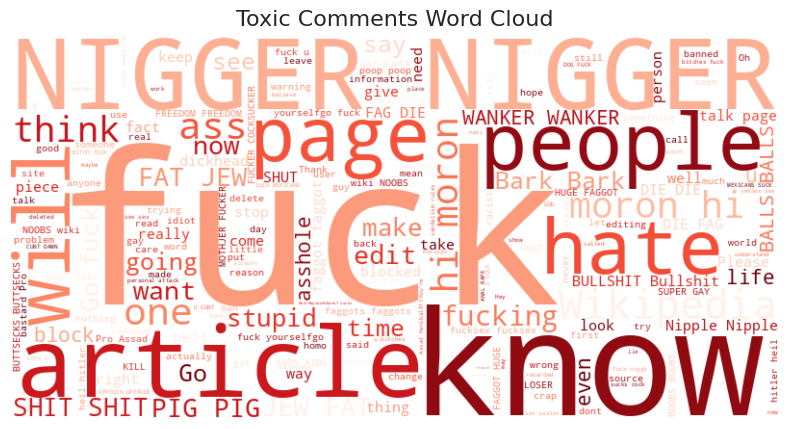

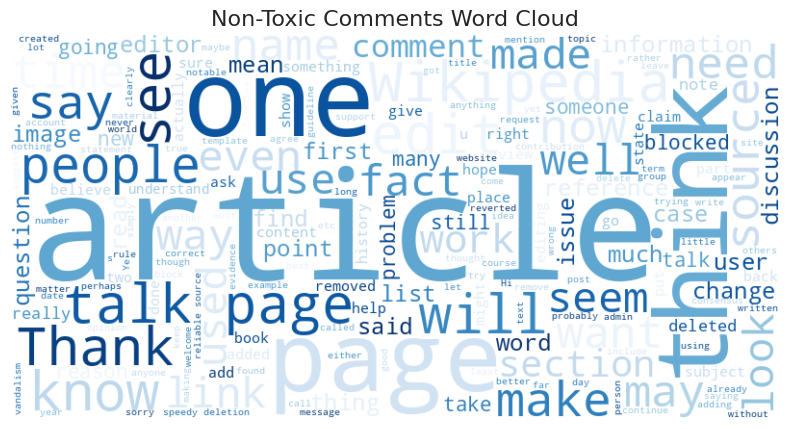

In [23]:
def generate_wordcloud(text_data, title, colormap='Reds'):
  text=' '.join(text_data)
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=colormap,
      max_words=200,
    ).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.show()

generate_wordcloud(train_df[train_df['any_toxic'] == 1]['comment_text'], 'Toxic Comments Word Cloud','Reds')
generate_wordcloud(train_df[train_df['any_toxic'] == 0]['comment_text'], 'Non-Toxic Comments Word Cloud', 'Blues')

Most frequent words and phrases in toxic comments.
*   Unigrams → single words
*   Bigrams → two-word combinations

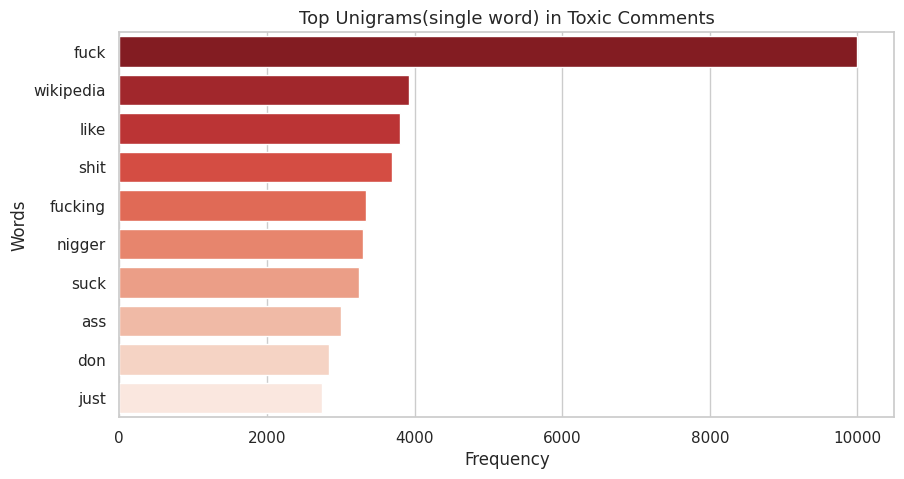

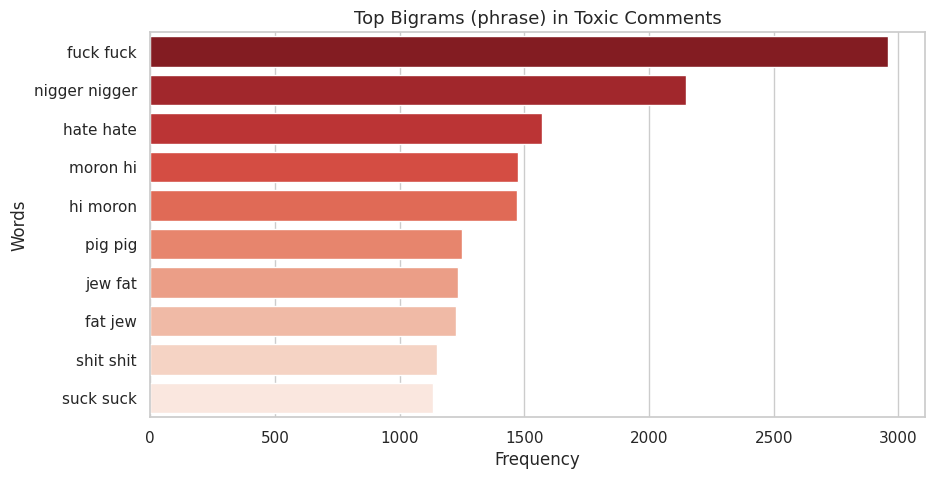

In [24]:
from numpy import vecdot
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams (corpus, title, ngram_range=(1,1), top_n=10):
  vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=1000).fit(corpus)
  bag_of_words = vec.transform(corpus)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  top_n_ngrams = words_freq[:top_n]
  words = [word for word, freq in top_n_ngrams]
  freq = [freq for word, freq in top_n_ngrams]

  plt.figure(figsize=(10, 5))
  sns.barplot(
    x=list(freq),
    y=list(words),
    hue=list(words),
    palette='Reds_r',
    legend=False
  )
  plt.title(title, fontsize=13)
  plt.xlabel('Frequency', fontsize=12)
  plt.ylabel('Words', fontsize=12)
  plt.show()

toxic_comments = train_df[train_df['any_toxic'] == 1]['comment_text'].dropna()

get_top_ngrams(toxic_comments, 'Top Unigrams(single word) in Toxic Comments', ngram_range=(1,1), top_n=10)
get_top_ngrams(toxic_comments, 'Top Bigrams (phrase) in Toxic Comments', ngram_range=(2,2), top_n=10)

# PreProcessing

**Raw data from the trained dataset before any
pre processing **

In [25]:
train_df[['comment_text', "toxic"]].sample(6)

,comment_text,toxic
144234,"Agreed, a test Ref Desk doesn't have to be per...",0
105434,"Sorry, looks like the posts on ANI have been a...",0
21587,"""\n\n Quantum fiction \n\nI'm sorry your decis...",0
145131,Contributions\n\nTaking a look at this users c...,0
61508,I don't agree with that. I could summarise eit...,0
25071,"Makes sense, they want to celebrate the 20th a...",0


**Basic Preprocessing**



1.   Lower case




In [26]:
def to_lower(text):
    return text.lower()


2.   URL remove



In [27]:
def remove_urls(text):
    import re
    return re.sub(r"http\S+|www\S+", "", text)


3. Mentions remove



In [28]:
def remove_mentions(text):
    import re
    return re.sub(r"@\w+", "", text)



4. Remove Punctuation



In [29]:
def remove_punctuation(text):
    import re
    return re.sub(r"[^a-zA-Z\s]", "", text)


5. Remove extra space




In [30]:
def remove_extra_spaces(text):
    import re
    return re.sub(r"\s+", " ", text).strip()

<!-- 6. Stopword removed -->

In [31]:
# def stopword_removal(text):
#     stopwords = {"the", "is", "a", "an"}
#     return " ".join([w for w in text.split() if w not in stopwords])

**Advance Preprocessing**

In [32]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 41.1 MB/s eta 0:00:00


1. Emoji to text

In [33]:
import emoji

def emoji_to_text(text):
  return emoji.demojize(text, delimiters=(" ", " "))

 2. Convert to full forms



In [34]:
# def expand_contractions(text):
#   contractions = {
#     "ain't": "is not",
#     "aren't": "are not",
#     "can't": "cannot",
#     "can't've": "cannot have",
#     "'cause": "because",
#     "don't": "do not",
#     "you're": "you are",
#     "it's": "it is",
#     "i'm": "i am",
#     "won't": "will not"
#   }
#   for k,v in contractions.items():
#       text = text.replace(k,v)
#       return text



In [35]:
def expand_contractions(text):
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "don't": "do not",
        "you're": "you are",
        "it's": "it is",
        "i'm": "i am",
        "won't": "will not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    return text

3. Normalize repetitions\
stuuuuupid → stupid

In [36]:
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

4. Bad Word Normalization\
b!tch = bitch

In [37]:
def normalize_obscene(text):
    text = text.replace("b!tch", "bitch")
    text = text.replace("f*ck", "fuck")
    text = text.replace("a$$", "ass")
    return text

5. Tokenization

In [38]:
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer

In [39]:
# sample_text = train_df['comment_text'].iloc[0]

# clean_text = advanced_preprocess(sample_text)
# tokens = word_tokenize(clean_text)
def tokenize_text(text):
    return word_tokenize(text)

In [40]:
# print("Original text:", sample_text)
# print("Clean text:", clean_text)
# print("Tokens:", tokens)

Stopwords

In [41]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# stop_words = set(stopwords.words('english'))
# stopwords=True
# if stopwords:
#         tokens = [t for t in tokens if t not in stop_words]
#         print("Tokens after removing stop words:", tokens)

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]


Lemmatize

In [42]:
# lemmatizer = WordNetLemmatizer()
# lemmatize=True
# if lemmatize:
#         tokens = [lemmatizer.lemmatize(t) for t in tokens]
#         print('tokens after Lammatization: ', tokens)

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

PreProcess function

In [43]:
def basic_preprocess(text):
    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)
    return text

In [44]:
# def advanced_preprocess(text,remove_sw=True,lemmatize=True):
#     text = emoji_to_text(text)
#     text = expand_contractions(text)
#     text = normalize_obscene(text)
#     text = normalize_repeated_chars(text)
#     text = to_lower(text)
#     text = remove_urls(text)
#     text = remove_mentions(text)
#     text = remove_punctuation(text)
#     text = remove_extra_spaces(text)
#     tokens = tokenize_text(text)
#     if lemmatize:
#         tokens = lemmatize_tokens(tokens)
#     return text

In [45]:
def advanced_preprocess(text, remove_sw=True, lemmatize=True):
    text = emoji_to_text(text)
    text = expand_contractions(text)
    text = normalize_obscene(text)
    text = normalize_repeated_chars(text)

    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize_text(text)

    if remove_sw:
        tokens = remove_stopwords(tokens)

    if lemmatize:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)

# Apply the preprocessing

Before Applying

In [46]:
pd.set_option('display.max_colwidth', None)
train_df["raw"] = train_df["comment_text"]
train_df[["raw"]].sample(5)


,raw
118425,"How do you create a references section on the page? I've tried looking at more notable pages, like 24 (TV Series) but it only says: on them."
66000,"There is no problem really. So, some are born here, some are born there. Now, every time has its place. All along a trail, so why not following it? In a good way, we are attached to places and find reasons to stay, and so far, to be, or to have been in Oregon is a good thing!"
17488,"Image:Bennynovember1989.jpg\nI have tagged Image:Bennynovember1989.jpg as , because it does not provide a fair use rationale. If you believe the image to be acceptable for fair use according to Wikipedia policy, please provide a rationale explaining as much, in accordance with the fair use rationale guideline, on the image description page. Some examples can be found at Wikipedia:Use rationale examples. Please also consider using or one of the other tags listed at Wikipedia:Image copyright tags/Non-free. Thank you."
156604,"""\n\n...and did you enjoy that scene in Full Metal Jacket where private Joker said """"John Wayne,..is that you?"""" unaware that the drill instructor could hear him?"""
17704,"""\nAnd I didn't even add that one! You know, I think it's official: You are having too damn much fun with that article! (But that's a good thing!) (talk) """


Applying Basic Preprocessing

In [47]:

train_df["basic_clean"] = train_df["raw"].apply(basic_preprocess)
train_df[["basic_clean"]].sample(5)

,basic_clean
27110,its generally agreed that deaths arent reported on in the news unless they are of political leaders heads of state etc or recieve heavy global media coverage since peter brocks death has received little media attention outside of australia and nz and given the comments on this page i have removed the entry
72085,an discussion hi a theres currently a discussion about bracketbot at the administrators noticeboard see wpanbracketbot sorry youre receiving this late it looks like the original poster forgot to notify you best talk
18928,darn you are smart cathy nice editing
51452,if you have any more sources about the ownership of ibrox stadium please take them to that talk page
118580,i am not a bot troll or vandal no evidence has been provided to prove that i am in fact an admin said he is doing a good job at keeping his identity hidden maybe this is because i am not a sock as per my cease and desist notice to toddst i now address this notice to all admins who take unjust action against me without proof or evidence if my account is not unblocked by monday am est i will take the legal action that is needed to address this liable claim i further will seek financial compensation from all parties involved


Comparison Of Raw and Basic Clean by Basic Preprocessing

In [48]:
pd.set_option('display.max_colwidth', None)
train_df[["raw", "basic_clean"]].sample(5)

,raw,basic_clean
130293,"""\n\n Creation Museum blog \n\nI'm not a creationist (as evidenced by my contributions). I used that source just as a direct quote that Ken Ham acknowledged that the incident occurred (or that his version of it occurred - that's why I cited it just as a statement from Ken Ham, not as a verifiable account of the incident). On Google, I wasn't able to find a major website which covered this incident other than the Creation """"museum""""'s blog. """,creation museum blog im not a creationist as evidenced by my contributions i used that source just as a direct quote that ken ham acknowledged that the incident occurred or that his version of it occurred thats why i cited it just as a statement from ken ham not as a verifiable account of the incident on google i wasnt able to find a major website which covered this incident other than the creation museums blog
136040,There is a fine line between promoting and elaborating tau.,there is a fine line between promoting and elaborating tau
17827,"""::(And don't forget the New Yorks Times poll of """"Shakespeare professors""""!) \n""",and dont forget the new yorks times poll of shakespeare professors
99881,"""==WARNING: MEMBER THE WIKIPEDIAN GREEK NATIONALISTIC JUNTA. By User:Balkan ==\nThere’s a well collaborated (London based) group of GREEK Wikipedia sysops/users that has been spotted to work systematically in full daily basis propagandazing ultra natioanalistic Greek POV, and distorting related articles. They intervene in any Balkan history and politics related article, pushing Greek POV, launch edit wars, and repeated reverts of vandalized by them versions, permanent deletions, block users, merges and redirects to deletetion of undesired new articles. Their main target is to distort all articles lelated to ISLAM, TURKEY, REBUBLIC OF MACEDONIA, BULGARIA, ALBANIA (CHAMERIA), THEIR MINORITIES IN GREECE AND THEIR HISTORY. They attack every article criticizing Greece transforming it to Greekish propaganda POV. They became maniacs in optimizing dark side of Greek history.They communicate each other by secret e-mails avoiding messages through their talk pages to avoid publicity. This group acting in a systematic way to revert articles, when one of member makes the limit of 3 reverts, one another continues with 4th revert to avoid punishment for violating 3rv rule.\n\nFurthermore they are suspected agents of Greek National Intelligence Service (E.Y.Π. Κυπατζήδες) and believers of ultra nationalistic organizations of Greek “national interests”, as L.A.O.S. and Chrissi Avgi. They are also multiple sockpuppets and impersonators of their group members. They are all schizophrenics web vandals unacceptible to wikipedian community. Balkan history has labelled such people as GREKOMANS, a form of mental malignacy cited in Larousse dictionaries. Their illusion is MEGALI IDEA of Greek nationalism-expandism.They have been allied with Armenian, Serbian and Cypriot extremists of similar interest. THEY HAVE CONSTITUTED A WIKIPEDIAN GUNG, A GREEK PRAPAGANDA LOBBY, A GREEK EPSILON TEAM. All member of group are very radical nationalists. They work continously in three shifts over day and night.\nTo verify chek their contributions, talk page, edits, deletions, blocks, directs, protected pages and act properly. Wikipedia isn’t the right place to propagandize for “God’s elit nations” as Greece.\n\nMembers of gung involved: \n\n user:Khoikhoi sysop , He’s the chief-manager of group, recently probated by Wikipedia, suspected agent of Greek intelligence\n user:Future Perfect at Sunrise (sysop), GREEK, close collaborator of Khoikhoi\n user:Aldux (sysop), ), close collaborator of Khoikhoi \n user:Tekleni GREEK ,confirmed multiple sock puppet \n user:Telex,GREEK, confirmed sock puppet\n user:NikoSilver GREEK, close collaborator of Euthymios, vassal of KhoiKhoi\n user:Euthymios GREEK, confirmed collaborator of Khkoikhoi and Future Perfect at Sunrise\n user:Hectorian GREEKTAB\n user:Politis, GRE

Applying Advanced Preprocessing

In [49]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [50]:
train_df["advanced_clean"] = train_df["raw"].apply(advanced_preprocess)
train_df[["advanced_clean"]].sample(5)

,advanced_clean
52856,pokemon black white um hi linkbean saw message understand didnt know bulbapedia wasnt reliable resource apologize making waste time delete kthxbai
69907,may utc well done rocksound survived baptism fire article also dragged ani frivolous vexatious attempt get trouble person took
2906,dear salvio thinkwikipedia place contribute people using wikipedia spread false information people perhaps also found way derive monetary benefit exposing people using admin power monetary gain good wikipedia remember esjay scandal get chance assert find alternative way thanks noblast
31263,invited categorywikipedians southern california though letter l plus random people id encountered elsewhere ill resume invitation tomorrow talk
155054,scum look che deserve worst kind death faggot little bitch suck ball


Comparison of Raw and Advanced Clean by Advanced Preprocessing


In [51]:
pd.set_option('display.max_colwidth', None)
train_df[["raw","advanced_clean"]].sample(5)

,raw,advanced_clean
125341,"I think like The Simpsons, there are very strong indications its a particular location but certain pieces of evidence disprove it simply to keep people continually guessing. As the article states it is the most likely setting. Yes the time zone might be different but more evidence proves it being California than any other location.",think like simpson strong indication particular location certain piece evidence disprove simply keep people continually guessing article state likely setting yes time zone might different evidence prof california location
108827,"""\nI was getting to that. Odd thing is, I got no edit conflict. - Talk """,getting odd thing got edit conflict talk
57760,"""\nBTW, on a whole different topic, I know you are a Hokie, and I heard that BBC World Service is running a program on the anniversary date (is it tomorrow?) with readings from professors and students who have written short stories and poetry. I've looked at the BBC website, but I cannot find a link. If you have XM or Sirius radio (or I suppose a shortwave), you can listen to it. I heard an advert, and it sounded emotional. Talk• Contributions """,btw whole different topic know hokie heard bbc world service running program anniversary date tomorrow reading professor student written short story poetry ive looked bbc website find link xm sirius radio suppose shortwave listen heard advert sounded emotional talk contribution
146771,"""\n\nFuck off. Jesus Christ, Ron Paul is a stupid fucking loser. Nobody gives a shit about that fart bag. You dumbshits. \ talk /""",fuck jesus christ ron paul stupid fucking loser nobody give shit fart bag dumbshits talk
134896,"""\n\nHello\n\nI noticed that you have wrote on my talk page. I do know the user McFly85 personally. We both were in a computer lab checking out wikipedia one time and we talked about how the quality of certain areas of articles were a little lacking. He also told me about his tattered history on wikipedia, where he had his user page edited, without consent, by SWD316/Moe Epsilon. Then, someone else vandalized SWD316's user page, and put the blame on mcfly, which I'm fairly sure he would not do. Mcfly did make a few other accounts during a RFA as he was worried that if SWD316 would be given moderator powers, that he would be unfairly banned. And if you look at Mcfly85's edit history, he has made a wealth of good edits, mainly proofreading issues, but also a lot with NPOV, stub sorting, and even creating an article every once in awhile. In my opinion, even with all the alleged sockpuppet abuse, mcfly85 has been a strong asset to wikipedia. If it wasn't for this user, as lot of previous errors and formatting mistakes would have gone unnoticed, and would harm the quality of this site. He had no intention of becoming a moderator, but always intended to improve, even if only slightly, any article that was lacking quality. I feel bad that the actions of Moe Elipson have pretty much caused mcfly, my friend, to lose trust in this site and he has since retired his name. He did come back under another name, and made some great edits, but then, was unfairly (IMO) banned for being a 'sockpuppet used abusively"""". There is a difference between being a sockpuppet and trying to use a new name to get a fresh start.\n\nBut I am not mcfly85. I am fairly new to being a serious editor on wikipedia, and I was just checking some various parts of the site. I then noticed on the RFAs section that this familiar name came up, and I saw mcfly's screenname in the questions answered by Moe Elpison. I really didn't want other users have what happened to mcfly happen to them, so I voted opposed, which I am allowed to do as a user. I do not feel that I """"unfairly influenced"""" the voters, I think the voting results would have been the same weather I had voted or not. And I have never heard of Araxen, and I did not create or am involved with that user. That vote should not have counted. \n\nI just wa

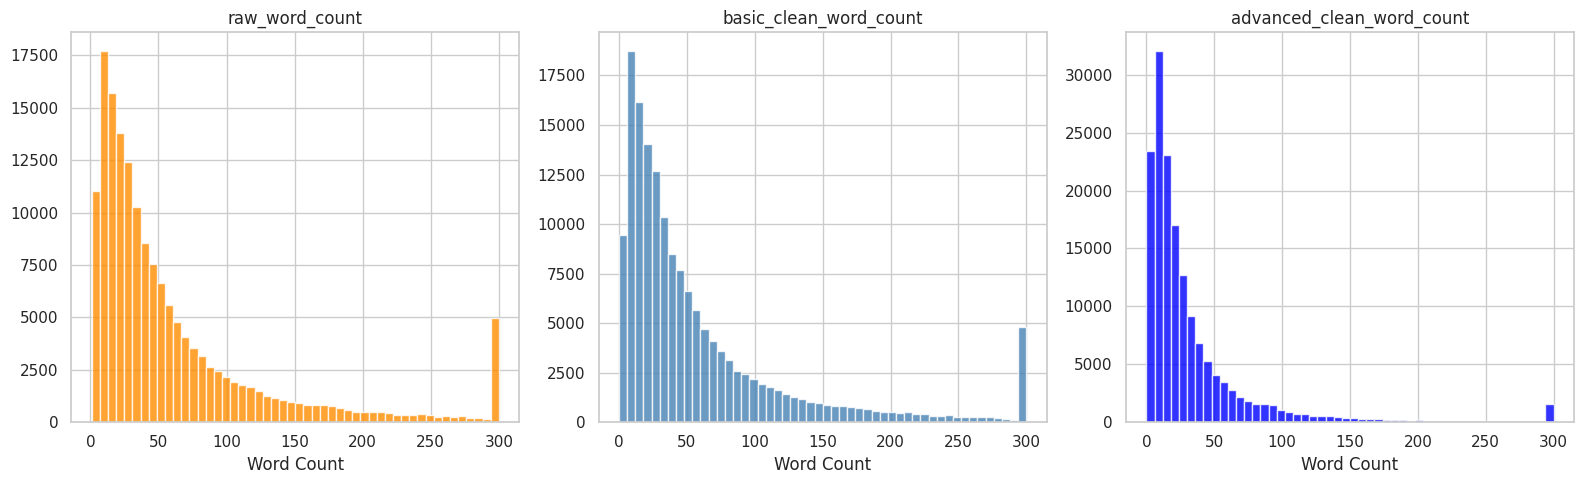

In [52]:
train_df['raw_word_count'] =train_df['comment_text'].str.split().str.len()
train_df['basic_clean_word_count'] =train_df['basic_clean'].str.split().str.len()
train_df['advanced_clean_word_count'] =train_df['advanced_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].hist(train_df['raw_word_count'].clip(upper=300),bins=50,color="darkorange", edgecolor='white',alpha=0.8)
axes[0].set_title('raw_word_count' , fontsize=12)
axes[0].set_xlabel('Word Count')


axes[1].hist(train_df['basic_clean_word_count'].clip(upper=300),bins=50,color="steelblue", edgecolor='white',alpha=0.8)
axes[1].set_title('basic_clean_word_count' , fontsize=12)
axes[1].set_xlabel('Word Count')


axes[2].hist(train_df['advanced_clean_word_count'].clip(upper=300),bins=50,color="blue", edgecolor='white',alpha=0.8)
axes[2].set_title('advanced_clean_word_count' , fontsize=12)
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [53]:
print('Raw text stats:')    ; print(train_df['raw_word_count'].describe().round(1))
print('\n basic Cleaned text stats:'); print(train_df['basic_clean_word_count'].describe().round(1))
print('\n advance Cleaned text stats:'); print(train_df['advanced_clean_word_count'].describe().round(1))


Raw text stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: raw_word_count, dtype: float64

 basic Cleaned text stats:
count    159571.0
mean         65.4
std          97.3
min           0.0
25%          16.0
50%          35.0
75%          73.0
max        1403.0
Name: basic_clean_word_count, dtype: float64

 advance Cleaned text stats:
count    159571.0
mean         34.0
std          52.5
min           0.0
25%           8.0
50%          18.0
75%          37.0
max        1250.0
Name: advanced_clean_word_count, dtype: float64


In [54]:
(train_df['basic_clean'] == train_df['advanced_clean']).sum()

np.int64(3383)

In [55]:
for i in range(2):
    print("RAW:", train_df['comment_text'].iloc[i])
    print("BASIC:", train_df['basic_clean'].iloc[i])
    print("ADVANCED:", train_df['advanced_clean'].iloc[i])
    print("-"*50)

RAW: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
BASIC: explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now
ADVANCED: explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please remove template talk page since im retired
--------------------------------------------------
RAW: D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
BASIC: daww he matches this background colour im seemingly stuck with thanks talk january utc
ADVANCED: daww match background colou

# Train  Validation  Test Split

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [57]:
x = train_df[['raw','basic_clean','advanced_clean']]
y = train_df[label_counts.index]

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df['any_toxic']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=y_temp.max(axis=1)
)

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')

Train : 127,656  |  Val : 15,957  |  Test : 15,958


# Feature Extraction

1. TF_IDF (for LR and SVM) \
use advanced_clean

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [59]:
tfidf = TfidfVectorizer(
    max_features=50000 ,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df =3
)
X_train_tfidf = tfidf.fit_transform(X_train['advanced_clean'])
X_val_tfidf = tfidf.transform(X_val['advanced_clean'])
X_test_tfidf = tfidf.transform(X_test['advanced_clean'])


In [60]:
print('TD_IFD shape train', X_train_tfidf.shape)
print('TD_IFD shape val', X_val_tfidf.shape)
print('TD_IFD shape test', X_test_tfidf.shape)

TD_IFD shape train (127656, 50000)
TD_IFD shape val (15957, 50000)
TD_IFD shape test (15958, 50000)


2. Tokenization & Padding (for LSTM) \
basic_clean

In [61]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import pad_sequences



In [62]:
Vocab_size =10000
max_len= 100

lstm_tok = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok.fit_on_texts(X_train['basic_clean'])

def to_padded(texts):
  seqs = lstm_tok.texts_to_sequences(texts)
  return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
X_train_lstm = to_padded(X_train['basic_clean'])
X_val_lstm = to_padded(X_val['basic_clean'])
X_test_lstm = to_padded(X_test['basic_clean'])

In [63]:
train_df['comment_text'].apply(lambda x: len(str(x).split())).describe()

,comment_text
count,159571.000000
mean,67.273527
std,99.230702
min,1.000000
25%,17.000000
50%,36.000000
75%,75.000000
max,1411.000000


In [64]:
print('LSTM shape train', X_train_lstm.shape)
print('LSTM shape val', X_val_lstm.shape)
print('LSTM shape test', X_test_lstm.shape)

LSTM shape train (127656, 100)
LSTM shape val (15957, 100)
LSTM shape test (15958, 100)


3. BERT Tokenizer (for BERT) \
raw dataset

In [65]:
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)

In [66]:
Bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def bert_encode(texts, max_len=512):
   enc =bert_tokenizer(
       list(texts),
       max_length=max_len,
       truncation=True,
       padding = 'max_length',
       return_tensors='tf'
   )
   return enc['input_ids'], enc['attention_mask']

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Evaluation toolkit
for comparing easily

In [67]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)


In [68]:
results ={}
def evaluate(model_name,y_true,y_pred, elapsed_train=None,elapsed_infer=None ):
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro',zero_division=0)
  rec = recall_score(y_true, y_pred, average='macro',zero_division=0)
  f1 = f1_score(y_true, y_pred, average='macro',zero_division=0)

  results[model_name] = {
      'accuracy': round(acc,4),
      'precision': round(prec,4),
      'recall': round(rec,4),
      'f1 (macro)': round(f1,4),
      'train time (s)':round( elapsed_train,1) if elapsed_train else '-',
      'infer time (s)': round(elapsed_infer,1) if elapsed_infer else '-'
  }
  print(f'\n===== {model_name} =====')
  print(f'  accuracy : {acc:.4f}')
  print(f'  precision: {prec:.4f}')
  print(f'  recall   : {rec:.4f}')
  print(f'  f1 Macro : {f1:.4f}')
  if elapsed_train: print(f'  train time: {elapsed_train:.1f}s')
  return results[model_name]


In [69]:
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score
# )

# results = {}

# def evaluate(model_name, y_true, y_pred, y_prob=None,
#              elapsed_train=None, elapsed_infer=None):

#     acc = accuracy_score(y_true, y_pred)

#     prec = precision_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     rec = recall_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     macro_f1 = f1_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     weighted_f1 = f1_score(
#         y_true, y_pred,
#         average='weighted',
#         zero_division=0
#     )

#     # ROC-AUC
#     if y_prob is not None:
#         roc_auc = roc_auc_score(
#             y_true,
#             y_prob,
#             average='macro'
#         )
#     else:
#         roc_auc = None

#     results[model_name] = {
#         'accuracy': round(acc, 4),
#         'precision': round(prec, 4),
#         'recall': round(rec, 4),
#         'macro f1': round(macro_f1, 4),
#         'weighted f1': round(weighted_f1, 4),
#         'roc-auc': round(roc_auc, 4) if roc_auc else '-',
#         'train time (s)': round(elapsed_train, 1) if elapsed_train else '-',
#         'infer time (s)': round(elapsed_infer, 1) if elapsed_infer else '-'
#     }

#     print(f'\n===== {model_name} =====')
#     print(f'Accuracy     : {acc:.4f}')
#     print(f'Precision    : {prec:.4f}')
#     print(f'Recall       : {rec:.4f}')
#     print(f'Macro F1     : {macro_f1:.4f}')
#     print(f'Weighted F1  : {weighted_f1:.4f}')

#     if roc_auc is not None:
#         print(f'ROC-AUC      : {roc_auc:.4f}')

#     if elapsed_train:
#         print(f'Train time   : {elapsed_train:.1f}s')

#     return results[model_name]

In [116]:
def plot_confusion(model_name,y_true, y_pred, lables=label_cols):
   fig, axes = plt.subplots( 2,3, figsize=(15,8))
   for ax, col in zip(axes.flatten(), labels):
       cm = confusion_matrix(y_true[:, labels.index(col)],
                              y_pred[:, labels.index(col)])
       sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues', cbar=False)
       ax.set_title(col, fontsize=11)
       ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
   plt.suptitle(f'Confusion Matrices — {model_name}', fontsize=14)
   plt.tight_layout()
   plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
   plt.show()

print('Evaluation helpers ready.')

Evaluation helpers ready.


# Model 1 — TF-IDF + Logistic Regression



## 1. Raw text version



In [71]:
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Model
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

No need train again

In [134]:
tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_raw = tfidf_raw.fit_transform(X_train['raw'])
X_test_tfidf_raw = tfidf_raw.transform(X_test['raw'])

lr_raw = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_raw.fit(X_train_tfidf_raw, y_train)
with open('lr_raw_model.pkl', 'wb') as f:
    pickle.dump(lr_raw, f)
with open('tfidf_raw_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_raw, f)


In [135]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_raw = lr_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0


Train time: 18.4s


Run the training

In [136]:
with open('lr_raw_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [137]:
with open('tfidf_raw_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

In [73]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [basic_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_raw.transform(sample_clean)

probs = lr_raw.predict_proba(sample_tfidf)

threshold = 0.5

for text, prob in zip(sample_comments, probs):

    print("\nComment:", text)

    toxic_found = False

    for label, p in zip(label_cols, prob):

        if p > threshold:
            toxic_found = True
            print(f"{label}: {p:.2%}")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: 100.00%
severe_toxic: 96.38%
obscene: 99.99%

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: 99.84%
severe_toxic: 82.45%
obscene: 96.65%

Comment: Amazing work
Prediction: Non-toxic


Evaluate the model for raw data

In [74]:
evaluate('TF-IDF + LR (raw)', y_test.values, y_pred_raw, train_t, infer_t)


===== TF-IDF + LR (raw) =====
  accuracy : 0.9204
  precision: 0.8366
  recall   : 0.3936
  f1 Macro : 0.5099
  train time: 17.7s


{'accuracy': 0.9204,
 'precision': 0.8366,
 'recall': 0.3936,
 'f1 (macro)': 0.5099,
 'train time (s)': 17.7,
 'infer time (s)': 0.0}

In [75]:
# y_prob_raw = lr_raw.predict_proba(X_test_tfidf_raw)

# evaluate(
#     'TF-IDF + LR (raw)',
#     y_test.values,
#     y_pred_raw,
#     y_prob=y_prob_raw,
#     elapsed_train=train_t,
#     elapsed_infer=infer_t
# )

Confusion plot for the model for raw data

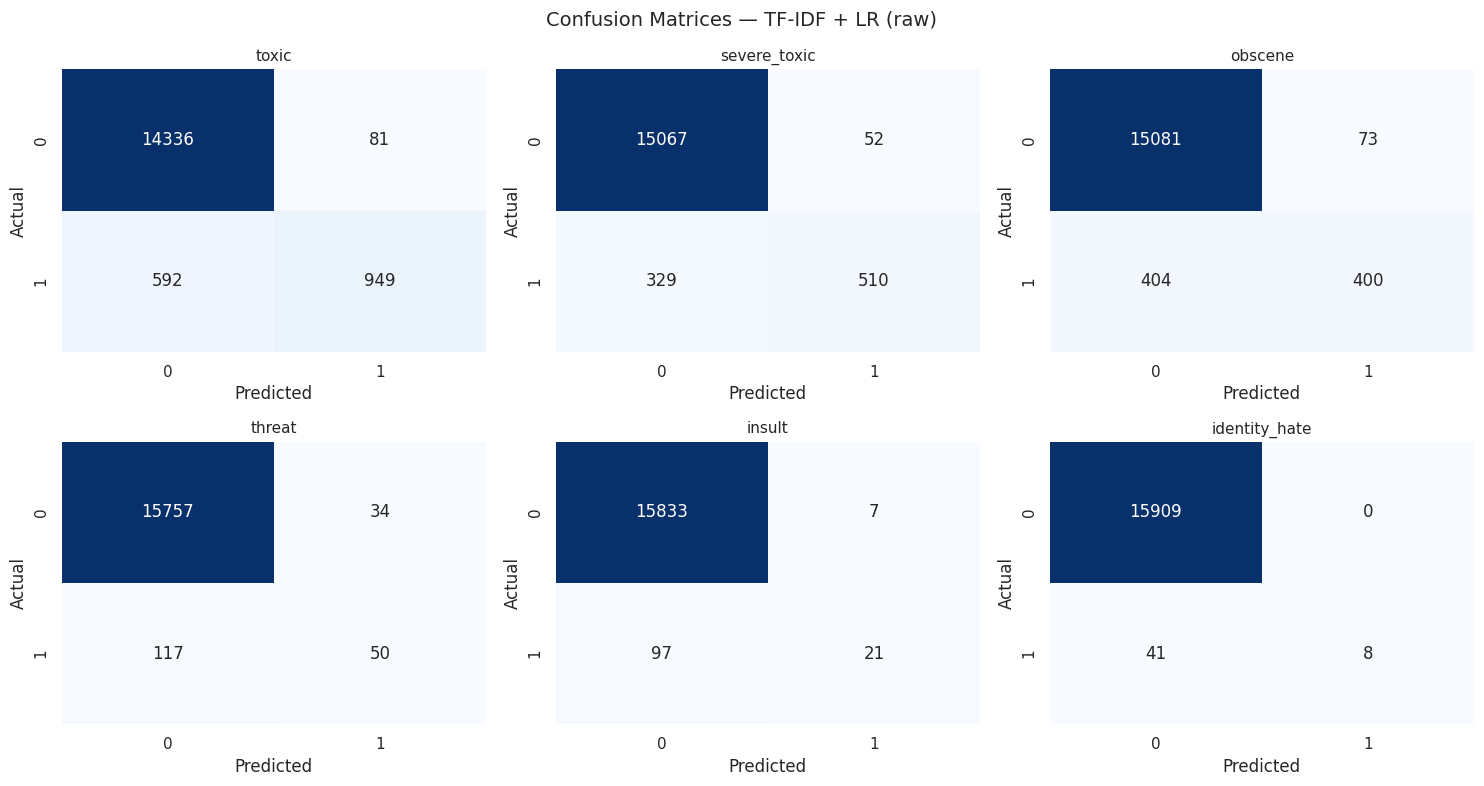

In [76]:
plot_confusion('TF-IDF + LR (raw)', y_test.values, y_pred_raw, label_cols)

## 2. Advanced clean version

**Also save the training so no need to re train **

In [130]:
tfidf_clean = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_clean = tfidf_clean.fit_transform(X_train['advanced_clean'])
X_test_tfidf_clean = tfidf_clean.transform(X_test['advanced_clean'])

lr_clean = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_clean.fit(X_train_tfidf_clean, y_train)
with open('lr_clean_model.pkl', 'wb') as f:
    pickle.dump(lr_clean, f)
with open('tfidf_clean_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_clean, f)

In [131]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_clean = lr_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 20.0s


**Load the training**

In [132]:
with open('lr_clean_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [133]:
with open('tfidf_clean_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

In [78]:
evaluate('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, train_t, infer_t)


===== TF-IDF + LR (advanced) =====
  accuracy : 0.9189
  precision: 0.7585
  recall   : 0.3845
  f1 Macro : 0.4852
  train time: 11.2s


{'accuracy': 0.9189,
 'precision': 0.7585,
 'recall': 0.3845,
 'f1 (macro)': 0.4852,
 'train time (s)': 11.2,
 'infer time (s)': 0.0}

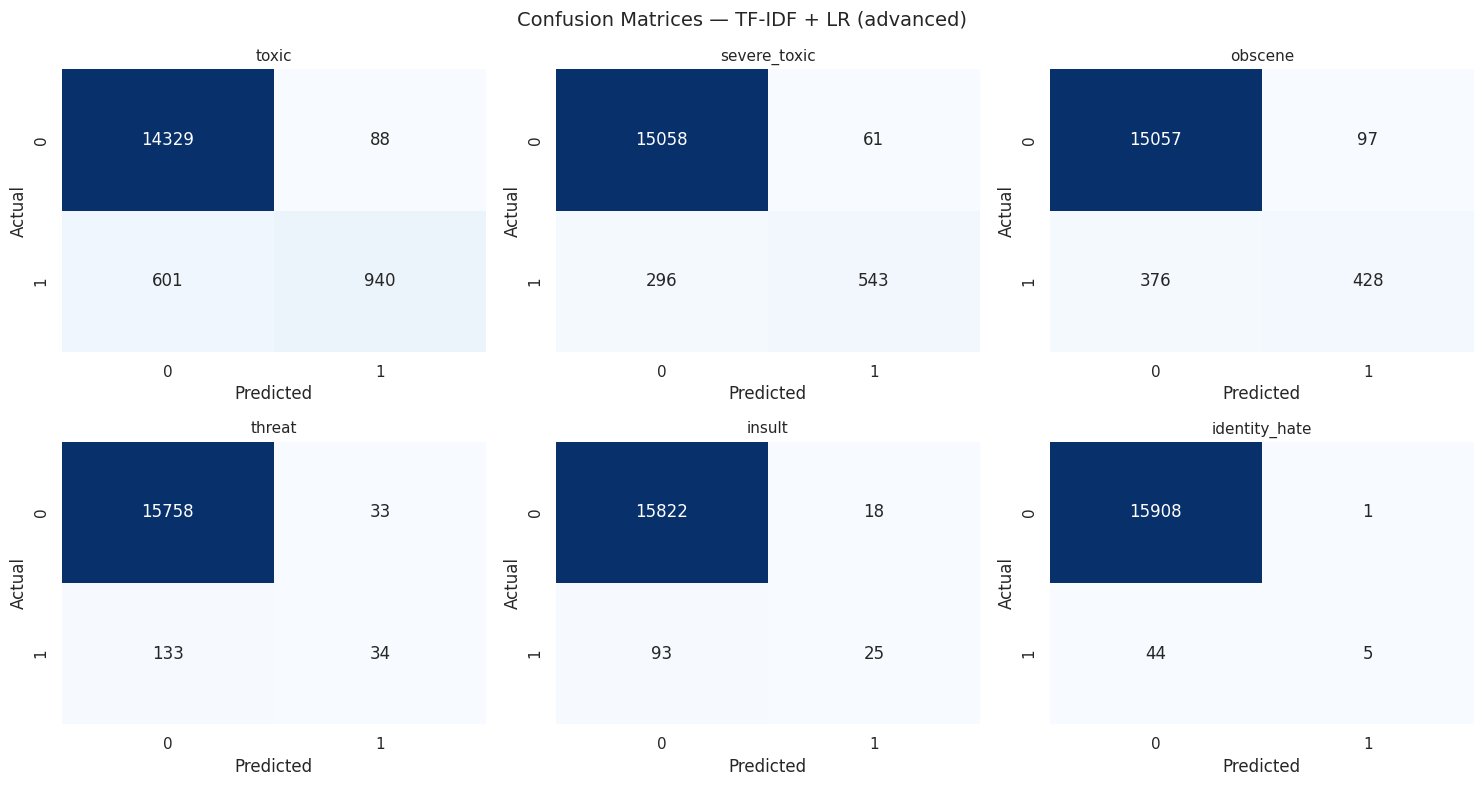

In [79]:
plot_confusion('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, label_cols)

The raw-text TF-IDF representation outperformed the advanced preprocessed version across all evaluation metrics. Excessive preprocessing may remove important contextual and emotional cues that contribute to toxicity identification.

In [80]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [advanced_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_clean.transform(sample_clean)

probs = lr_clean.predict_proba(sample_tfidf)

threshold = 0.5

for text, prob in zip(sample_comments, probs):

    print("\nComment:", text)

    toxic_found = False

    for label, p in zip(label_cols, prob):

        if p > threshold:
            toxic_found = True
            print(f"{label}: {p:.2%}")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: 100.00%
severe_toxic: 98.77%
obscene: 100.00%

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: 99.96%
severe_toxic: 89.89%
obscene: 98.20%

Comment: Amazing work
Prediction: Non-toxic


# **Model 2 — TF-IDF + SVM (LinearSVC)**

**Raw version **

In [81]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

No need to re run

In [138]:
svm_raw = OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_raw.fit(X_train_tfidf_raw, y_train)
with open('svm_raw_model.pkl', 'wb') as f:
    pickle.dump(svm_raw, f)

In [139]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_raw = svm_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0

Train time: 11.5s


load the train

In [140]:
with open('svm_raw_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [83]:
evaluate('TF-IDF + SVM (raw)', y_test.values, y_pred_svm_raw, train_t, infer_t)


===== TF-IDF + SVM (raw) =====
  accuracy : 0.9209
  precision: 0.7476
  recall   : 0.5065
  f1 Macro : 0.5944
  train time: 12.3s


{'accuracy': 0.9209,
 'precision': 0.7476,
 'recall': 0.5065,
 'f1 (macro)': 0.5944,
 'train time (s)': 12.3,
 'infer time (s)': 0.0}

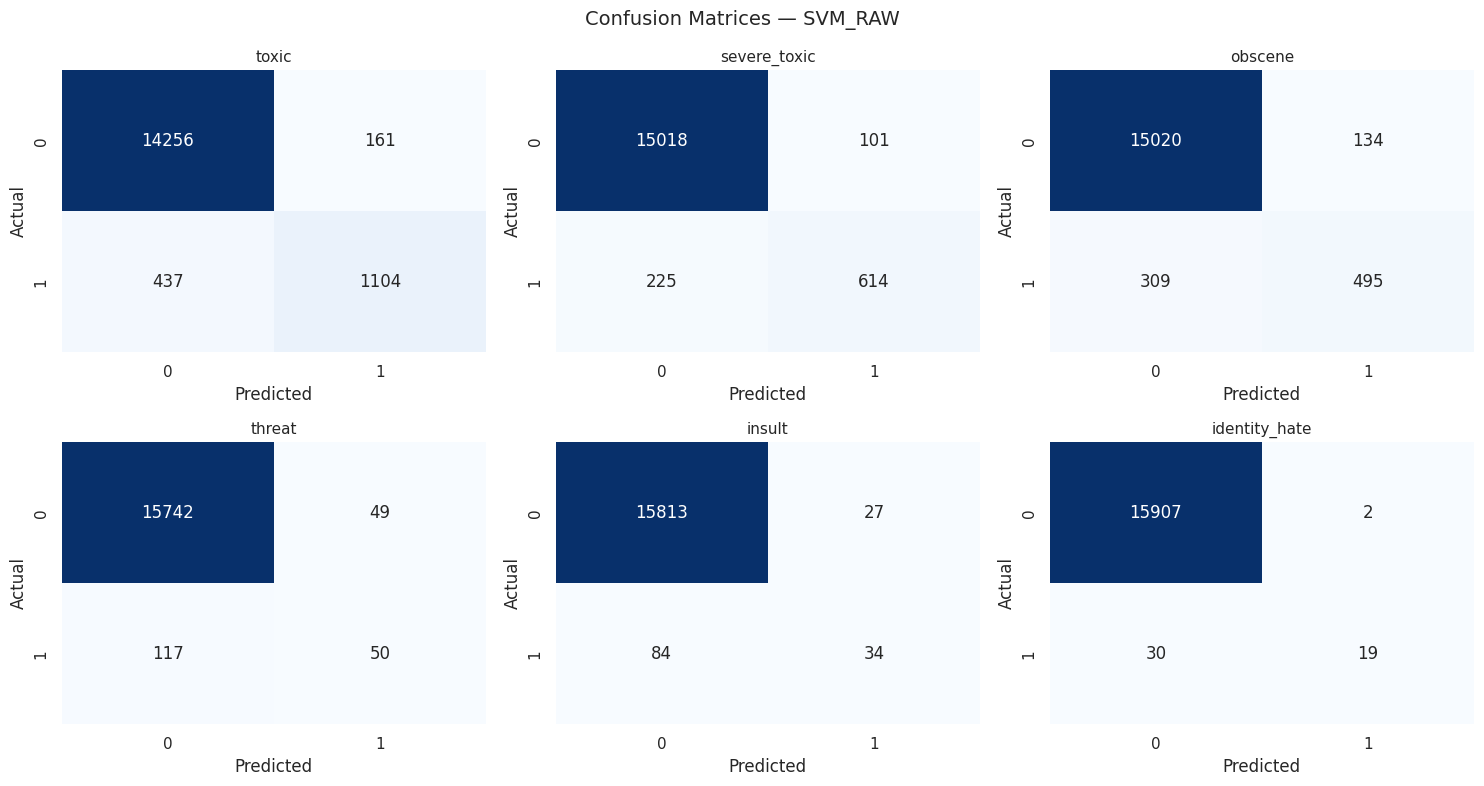

In [84]:
plot_confusion('SVM_RAW',y_test.values,y_pred_svm_raw,label_cols)

In [85]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [basic_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_raw.transform(sample_clean)
sample_pred = svm_raw.predict(sample_tfidf)

for text, pred in zip(sample_comments, sample_pred):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


**Advanced clean version**

In [141]:
svm_clean= OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_clean.fit(X_train_tfidf_clean, y_train)
with open('svm_clean_model.pkl', 'wb') as f:
    pickle.dump(svm_clean, f)


In [142]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_clean = svm_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 5.9s


In [143]:
with open('svm_clean_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [87]:
evaluate('TF-IDF + SVM (advanced)', y_test.values, y_pred_svm_clean, train_t, infer_t)


===== TF-IDF + SVM (advanced) =====
  accuracy : 0.9187
  precision: 0.7193
  recall   : 0.4957
  f1 Macro : 0.5780
  train time: 4.4s


{'accuracy': 0.9187,
 'precision': 0.7193,
 'recall': 0.4957,
 'f1 (macro)': 0.578,
 'train time (s)': 4.4,
 'infer time (s)': 0.0}

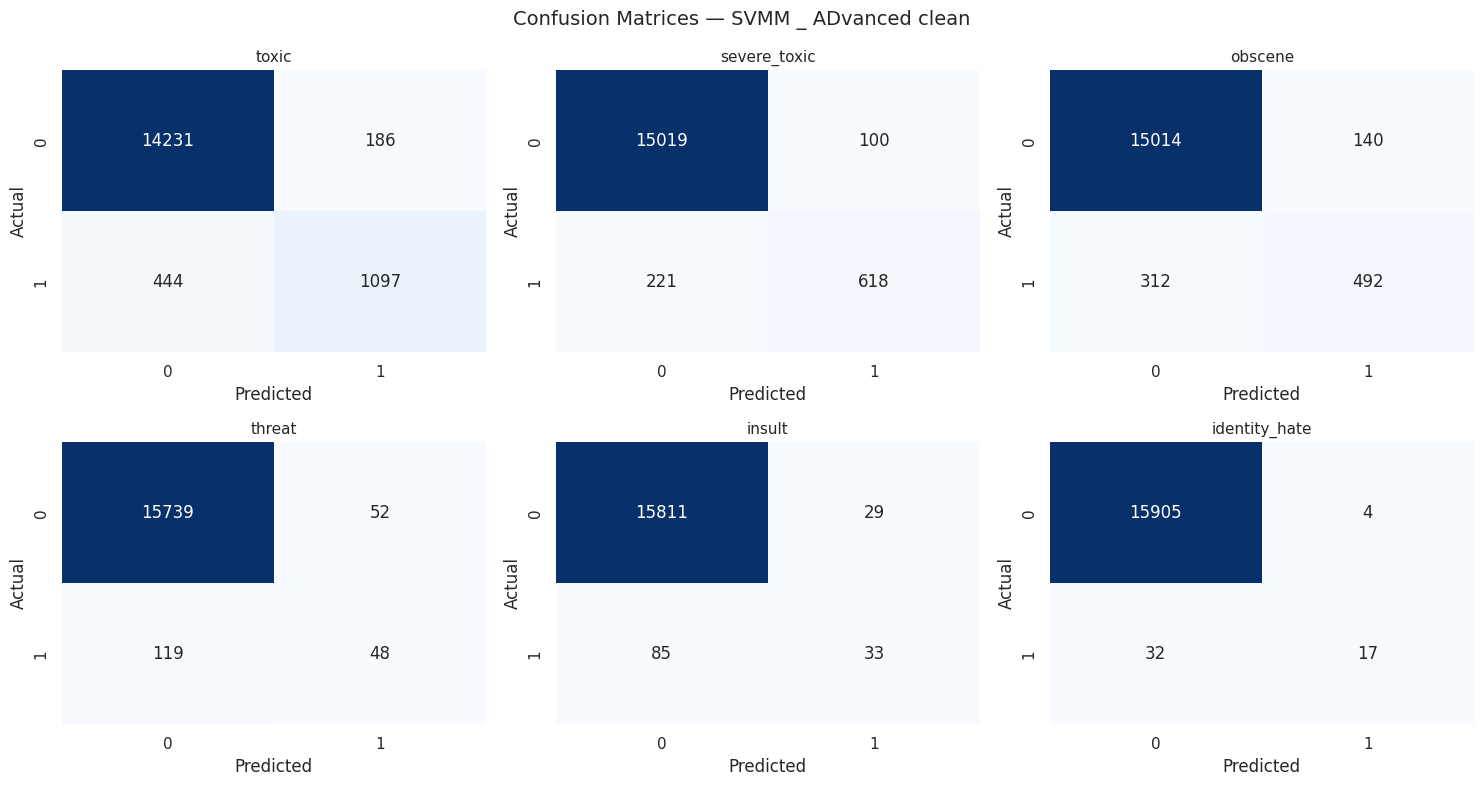

In [88]:
plot_confusion("SVMM _ ADvanced clean", y_test.values, y_pred_svm_clean, label_cols)

In [89]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

# preprocess
sample_clean = [advanced_preprocess(t) for t in sample_comments]

# tfidf transform
sample_tfidf = tfidf_raw.transform(sample_clean)

# prediction
sample_pred = svm_raw.predict(sample_tfidf)

for text, pred in zip(sample_comments, sample_pred):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


# Model 3 — Bidirectional LSTM

In [90]:
from tensorflow.keras.layers import (Input, Embedding, LSTM, Dense,
                                      Dropout, Bidirectional, GlobalMaxPooling1D)


Building the model



In [91]:
EMBED_DIM = 128
NUM_LABELS = len(label_cols)

def build_bilstm(Vocab_size, max_len, num_labels):
    inp  = Input(shape=(max_len,))
    x    = Embedding(Vocab_size, EMBED_DIM)(inp)
    x    = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2))(x)
    x    = GlobalMaxPooling1D()(x)
    x    = Dense(128, activation='relu')(x)
    x    = Dropout(0.3)(x)
    out  = Dense(num_labels, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [92]:
lstm_model = build_bilstm(Vocab_size , max_len, NUM_LABELS)
lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,396,102 (5.33 MB)

 Trainable params: 1,396,102 (5.33 MB)

 Non-trainable params: 0 (0.00 B)

Training the modle

In [93]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Model




saved the train

In [144]:
callbacks =[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)
            ]
t0=time.time()
history = lstm_model.fit(
    X_train_lstm, y_train.values,
    validation_data=(X_val_lstm, y_val.values),
    epochs=10,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)
lstm_model.save("bilstm_model.h5")

Epoch 1/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9067 - loss: 0.0395 - val_accuracy: 0.9925 - val_loss: 0.0511 - learning_rate: 1.2500e-04
Epoch 2/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.8798 - loss: 0.0388 - val_accuracy: 0.9915 - val_loss: 0.0517 - learning_rate: 1.2500e-04
Epoch 3/10
995/998 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8932 - loss: 0.0395
Epoch 3: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.8642 - loss: 0.0381 - val_accuracy: 0.9747 - val_loss: 0.0523 - learning_rate: 1.2500e-04
Epoch 4/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.8547 - loss: 0.0373 - val_accuracy: 0.9625 - val_loss: 0.0527 - learning_rate: 6.2500e-05


In [145]:
train_t = time.time() - t0

print(f'Train time: {train_t:.1f}s')

Train time: 79.1s


In [146]:
from tensorflow.keras.models import load_model

loaded_lstm = load_model("bilstm_model.h5")

Plot training curves

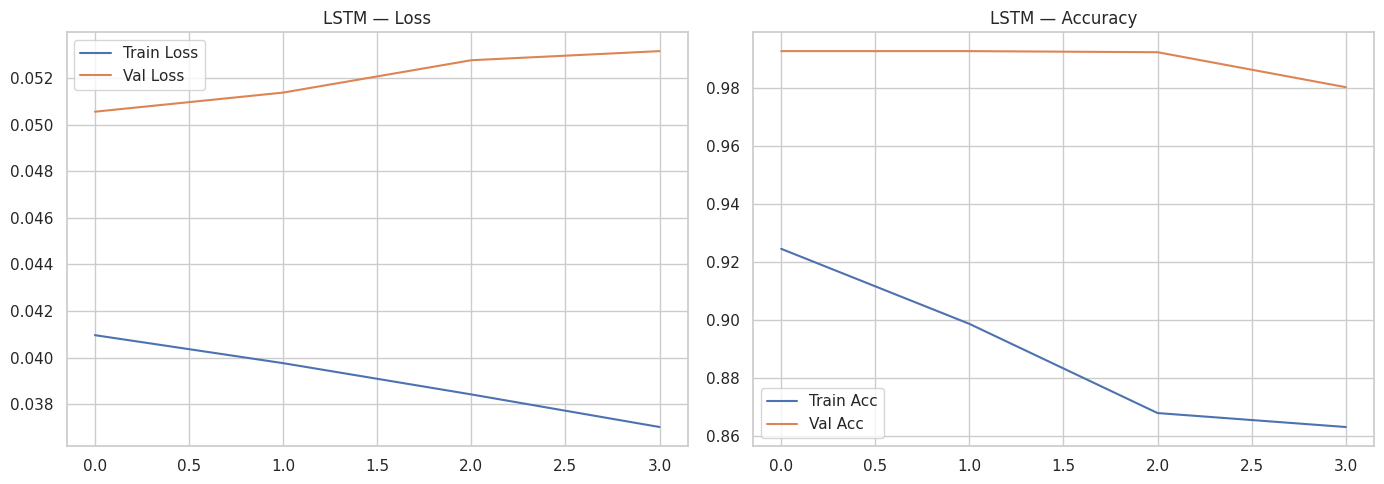

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM — Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('LSTM — Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [96]:
# Evaluate LSTM — Basic Clean (primary)
t0 = time.time()
y_pred_lstm = (lstm_model.predict(X_test_lstm) > 0.5).astype(int)
lstm_infer_t = time.time() - t0

evaluate('LSTM — Basic Clean', y_test.values, y_pred_lstm,
         train_t, lstm_infer_t)

499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

===== LSTM — Basic Clean =====
  accuracy : 0.9186
  precision: 0.4886
  recall   : 0.4351
  f1 Macro : 0.4556
  train time: 91.8s


{'accuracy': 0.9186,
 'precision': 0.4886,
 'recall': 0.4351,
 'f1 (macro)': 0.4556,
 'train time (s)': 91.8,
 'infer time (s)': 3.2}

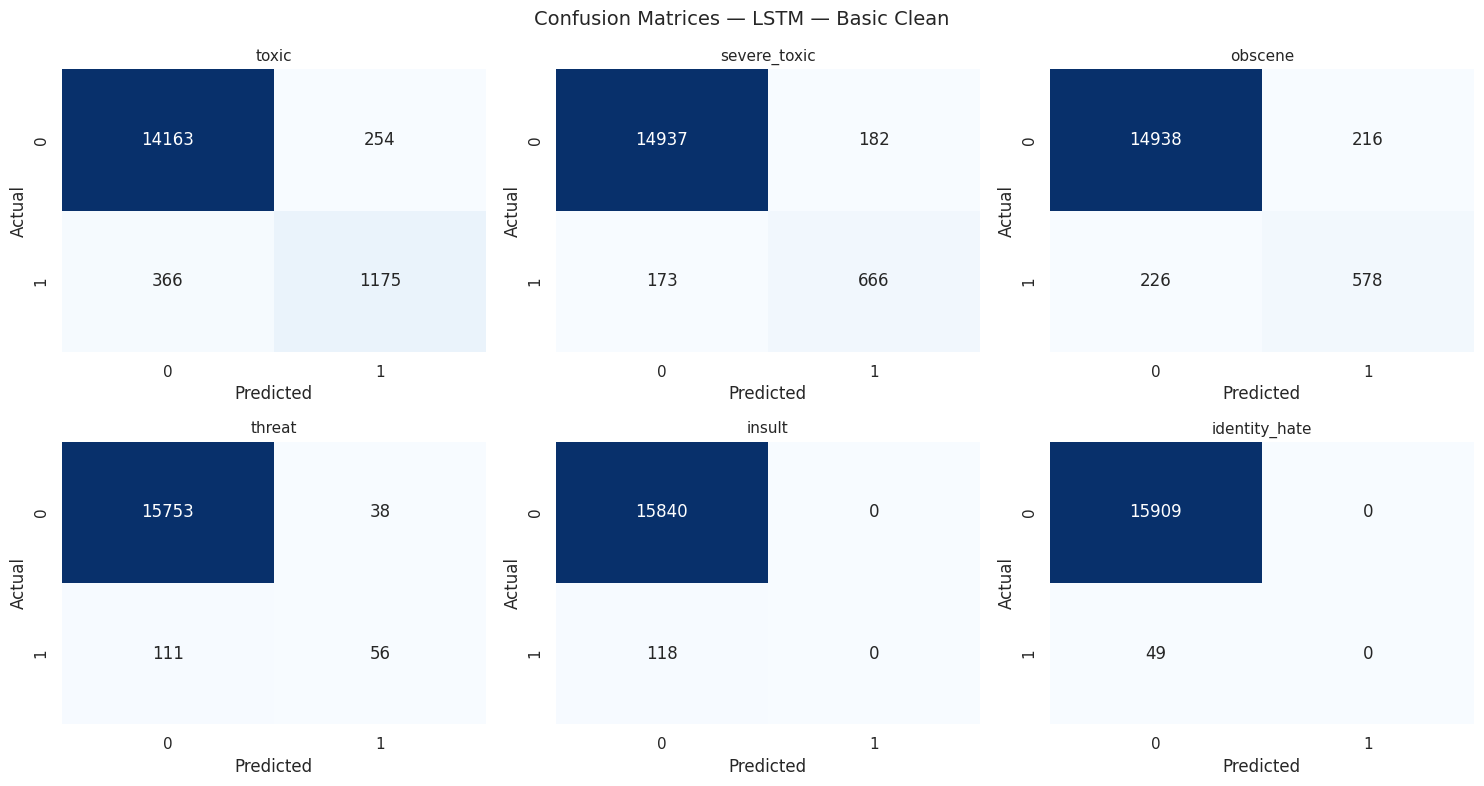

In [97]:
plot_confusion('LSTM — Basic Clean', y_test.values, y_pred_lstm,label_cols)

BiLSTM with raw data


In [147]:
lstm_tok_raw = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok_raw.fit_on_texts(X_train['raw'])

def to_padded_raw(texts):
    seqs = lstm_tok_raw.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen= max_len ,padding='post', truncating='post')

X_train_lstm_raw = to_padded_raw(X_train['raw'])
X_val_lstm_raw   = to_padded_raw(X_val['raw'])
X_test_lstm_raw  = to_padded_raw(X_test['raw'])

lstm_raw_model = build_bilstm(Vocab_size, max_len, NUM_LABELS)

t0 = time.time()
lstm_raw_model.fit(
    X_train_lstm_raw, y_train.values,
    validation_data=(X_val_lstm_raw, y_val.values),
    epochs=10, batch_size=256,
    callbacks=callbacks, verbose=1
)
lstm_model.save("lstm_raw_model.h5")


Epoch 1/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8721 - loss: 0.0924 - val_accuracy: 0.9927 - val_loss: 0.0515 - learning_rate: 0.0010
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9708 - loss: 0.0492 - val_accuracy: 0.9927 - val_loss: 0.0504 - learning_rate: 0.0010
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9670 - loss: 0.0455 - val_accuracy: 0.9927 - val_loss: 0.0502 - learning_rate: 0.0010
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9517 - loss: 0.0419 - val_accuracy: 0.9927 - val_loss: 0.0513 - learning_rate: 0.0010
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9480 - loss: 0.0395
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9340 - loss: 0.0385 - val_accuracy: 0.9927 - val_loss: 0.0535 - learning_rate: 0.0010
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9173 - los

In [148]:
lstm_raw_train_time = time.time() - t0

t0 = time.time()
y_pred_lstm_raw = (lstm_raw_model.predict(X_test_lstm_raw) > 0.5).astype(int)
lstm_raw_infer = time.time() - t0

499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


In [ ]:
loaded_lstm = load_model("lstm_raw_model.h5")

In [99]:
evaluate('LSTM — Raw', y_test.values, y_pred_lstm_raw, lstm_raw_train_time, lstm_raw_infer)


===== LSTM — Raw =====
  accuracy : 0.9182
  precision: 0.4971
  recall   : 0.3866
  f1 Macro : 0.4062
  train time: 37.9s


{'accuracy': 0.9182,
 'precision': 0.4971,
 'recall': 0.3866,
 'f1 (macro)': 0.4062,
 'train time (s)': 37.9,
 'infer time (s)': 3.0}

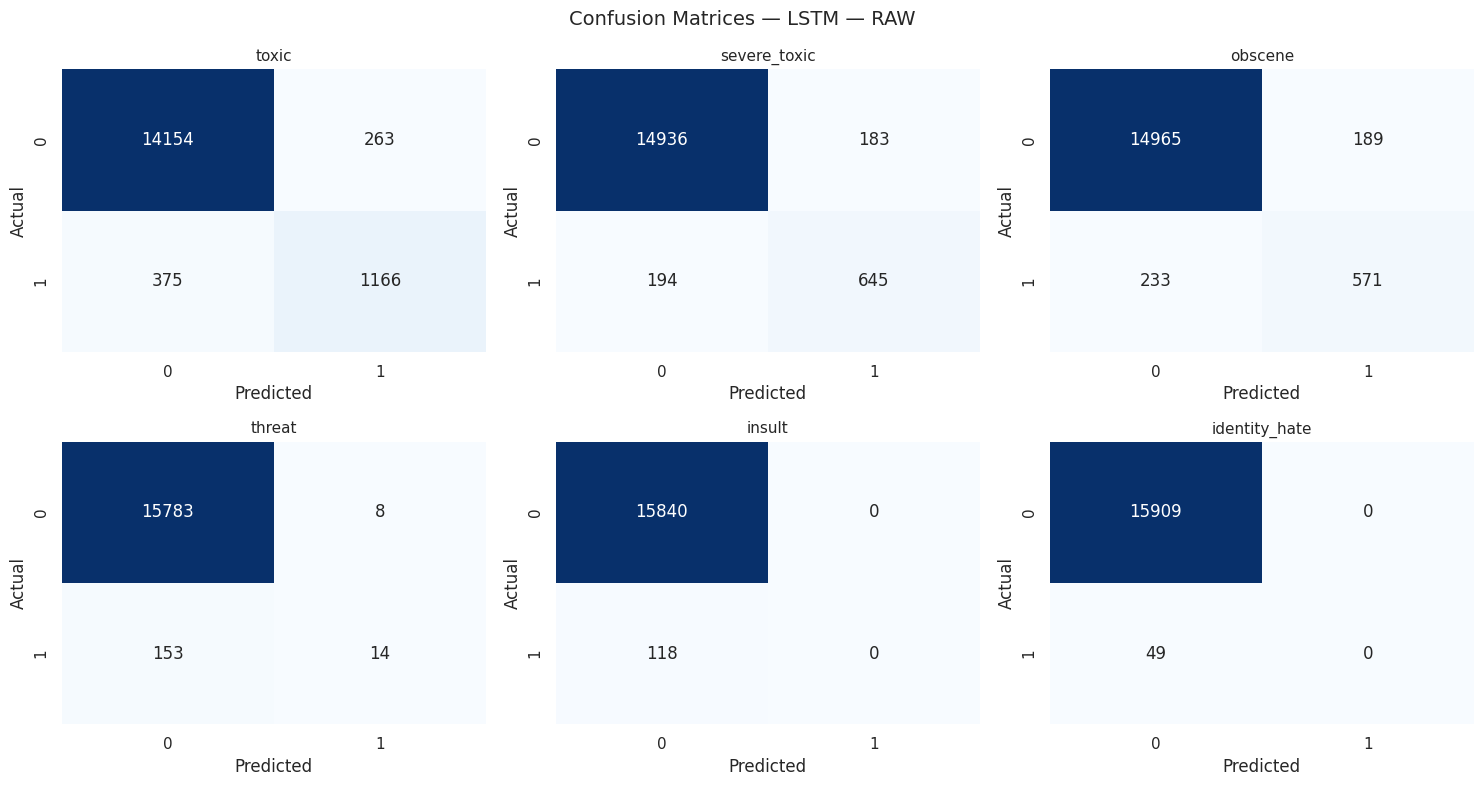

In [100]:
plot_confusion('LSTM — RAW', y_test.values, y_pred_lstm_raw,label_cols)

# Model 4 — BERT (Fine-tuned)

In [101]:
import torch
from torch.optim import AdamW
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.utils.data import Dataset, DataLoader

In [102]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Dataset
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = list(texts)
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.float)
        }

Device: cuda


if want to faster then bert_bath increase

or bert epochs 1

In [103]:
# Hyperparameters
BERT_BATCH = 32
BERT_EPOCHS = 1
BERT_MAX_LEN = 48

# Create datasets
train_ds = ToxicDataset(X_train['raw'].tolist(), y_train.values, Bert_tokenizer, BERT_MAX_LEN)
val_ds   = ToxicDataset(X_val['raw'].tolist(), y_val.values, Bert_tokenizer, BERT_MAX_LEN)
test_ds  = ToxicDataset(X_test['raw'].tolist(), y_test.values, Bert_tokenizer, BERT_MAX_LEN)


In [104]:
# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BERT_BATCH, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BERT_BATCH)
test_loader  = DataLoader(test_ds, batch_size=BERT_BATCH)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 3990
Val batches: 499


load model

In [115]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

In [106]:
bert_model = BertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_LABELS,
    problem_type='multi_label_classification'
).to(DEVICE)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

You are using a model of type distilbert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights: 0it [00:00, ?it/s]

BertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin1.weight          | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.weight   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.weight          | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin1.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.bias   | UNEXPECTED | 
distilbert.embeddings.position_embeddi

Optimizer & scheduler

In [107]:
optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

total_steps = len(train_loader) * BERT_EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

criterion = torch.nn.BCEWithLogitsLoss()

print("BERT model ready.")

BERT model ready.


Training function

In [108]:
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()

    total_loss = 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(train):

        for batch in loader:

            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(outputs.logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0
                )

                optimizer.step()
                scheduler.step()

            total_loss += loss.item()

            preds = (
                torch.sigmoid(outputs.logits) > 0.5
            ).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        np.vstack(all_preds),
        np.vstack(all_labels)
    )

Training Loop

Expected 20 min

In [112]:
best_val_loss = float('inf')
bert_train_losses = []
bert_val_losses = []

for epoch in range(BERT_EPOCHS):

    start = time.time()

    train_loss, _, _ = run_epoch(
        bert_model,
        train_loader,
        train=True
    )

    val_loss, val_preds, val_labels = run_epoch(
        bert_model,
        val_loader,
        train=False
    )

    val_f1 = f1_score(
        val_labels,
        val_preds,
        average='macro',
        zero_division=0
    )

    elapsed = time.time() - start

    print(
        f'Epoch {epoch+1}/{BERT_EPOCHS} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Val F1: {val_f1:.4f} | '
        f'Time: {elapsed:.0f}s'
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            bert_model.state_dict(),
            'best_bert.pt'
        )
    bert_train_losses.append(train_loss)
    bert_val_losses.append(val_loss)

print("Training complete.")

Epoch 1/1 | Train Loss: 0.0586 | Val Loss: 0.0554 | Val F1: 0.3987 | Time: 1287s
Training complete.


In [149]:
import os
print(os.listdir())

['.config', 'lr_clean_model.pkl', 'cm_SVM_RAW.png', 'cm_SVMM___ADvanced_clean.png', 'cm_LSTM_—_RAW.png', 'tfidf_clean_vectorizer.pkl', 'svm_clean_model.pkl', 'co_occurrence_matrix.png', 'lstm_raw_model.h5', 'word_count_distribution.png', 'bert_loss_curve.png', 'svm_raw_model.pkl', 'cm_TF-IDF_+_LR_(raw).png', 'lstm_training_curves.png', 'cm_LSTM_—_Basic_Clean.png', 'tfidf_raw_vectorizer.pkl', 'cm_TF-IDF_+_LR_(advanced).png', 'label_distribution.png', 'bilstm_model.h5', 'best_bert.pt', 'lr_raw_model.pkl', 'sample_data']


loss curve

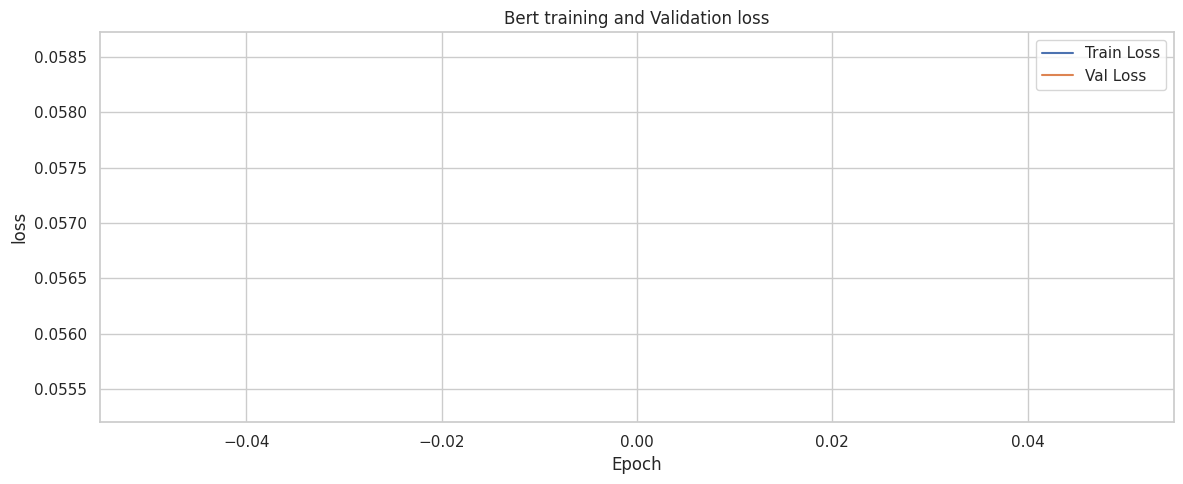

In [119]:
plt.plot(bert_train_losses, label='Train Loss')
plt.plot(bert_val_losses, label='Val Loss')
plt.title('Bert training and Validation loss')
plt.xlabel('Epoch'); plt.ylabel('loss'); plt.legend()
plt.tight_layout()
plt.savefig('bert_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()